# 01-3. Train Shared-E2E Encoder-Representation Projected

기존 `shared_e2e`의 forward, GT-center sampler, residual adapter, shared bbox head, inference는 그대로 유지합니다. 달라지는 부분은 backward 한 곳뿐입니다. 공유 encoder 출력 `E`에서 `∂L_cls/∂E · ∂L_aux/∂E < 0`일 때만 auxiliary gradient의 classification 반대 성분을 제거합니다. main localization gradient와 encoder 출력 이후의 decoder, bbox head, adapter gradient는 수정하지 않습니다. 교정된 하나의 total gradient만 encoder와 backbone으로 역전파됩니다.

이 노트북은 먼저 수학적 projection과 실제 한 batch 구조 불변식을 검사하고, Shared-E2E와 representation projection V2의 한-step 시간·peak CUDA memory를 비교한 다음 seed 42/43/44를 학습합니다. 매 step의 raw cosine/dot/norm, projected norm, 적용 여부, 제거 비율과 epoch conflict rate를 CSV에 기록합니다.

In [3]:
from pathlib import Path
import gc, importlib, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.model as model_module
import gt_aux.eval as eval_module
import gt_aux.train as train_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
model_module = importlib.reload(model_module)
eval_module = importlib.reload(eval_module)
train_module = importlib.reload(train_module)

ExperimentConfig = config_module.ExperimentConfig
prepare_data, make_loaders = data_module.prepare_data, data_module.make_loaders
make_model = model_module.make_model
project_conflicting_gradient = train_module.project_conflicting_gradient
representation_projected_gradients = train_module.representation_projected_gradients
register_representation_gradient_correction = train_module.register_representation_gradient_correction
move_labels_to_device = train_module.move_labels_to_device
train_one_experiment = train_module.train_one_experiment
release_model = train_module.release_model

## 1. 고정 실험 설정

기존 smoke 비교와 같은 split 및 학습 조건을 사용합니다. 완료된 checkpoint/history는 건너뛰고, 부분 실행은 같은 checkpoint에서 optimizer, scheduler, scaler, RNG 상태까지 이어서 학습합니다.

In [4]:
RUN_MODE = 'full'
SEEDS = [42]
DATA_SEED = 42
EXPERIMENT = 'shared_e2e_rep_projected'
REFERENCE_EXPERIMENTS = ['baseline', 'shared_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 3000, 750, 20
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 640, 1000
RUN_TRAINING = True
RUN_STRUCTURE_PROBE = False
RUN_COST_BENCHMARK = False
RESUME_FROM_BY_SEED = {}  # 예: {42: Path('cache/checkpoints/shared_e2e_rep_projected/seed_42/...pt')}

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=[EXPERIMENT], train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_min_size=IMAGE_MIN_SIZE,
    image_max_size=IMAGE_MAX_SIZE, feature_level=0, base_aux_weight=0.5,
    checkpoint_group='shared_e2e_projected_full',
)
CONFIG.as_dict()

{'root': 'D:\\gt-super',
 'run_mode': 'full',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 3000,
 'val_images': 750,
 'epochs': 20,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 640, 'longest_edge': 1000},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'checkpoint_group': 'shared_e2e_projected_full',
 'device': 'cuda',
 'experiments': ['shared_e2e_rep_projected'],
 'seed': 42,
 'data_seed': 42}

In [5]:
BUNDLE = prepare_data(CONFIG)
train_loader, _ = make_loaders(CONFIG, BUNDLE, SEEDS[0])
probe_batch = next(iter(train_loader))
print(f'train={len(BUNDLE.train_records)}, val={len(BUNDLE.val_records)}, device={CONFIG.device}')
print(f'probe batch={tuple(probe_batch["pixel_values"].shape)}')

VOC XML: 100%|██████████| 3750/3750 [00:06<00:00, 566.89it/s]


Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=3000, val=750
train=3000, val=750, device=cuda
probe batch=(2, 3, 640, 960)


## 2. Projection 수학 단위 검사

충돌 벡터는 projection 후 내적이 0이 되고, 협력 벡터는 bitwise 그대로 남아야 합니다.

In [6]:
g_cls = (torch.tensor([1.0, 0.0]), torch.tensor([0.0, 2.0]))
g_aux_conflict = (torch.tensor([-2.0, 3.0]), torch.tensor([1.0, -1.0]))
g_aux_safe, synthetic_stats = project_conflicting_gradient(g_cls, g_aux_conflict)
safe_dot = sum((a * b).sum() for a, b in zip(g_cls, g_aux_safe))
assert synthetic_stats['projection_applied']
assert synthetic_stats['enc_cls_aux_dot_raw'] < 0
assert abs(float(safe_dot)) < 1e-6

g_aux_aligned = (torch.tensor([2.0, 3.0]), torch.tensor([1.0, 1.0]))
unchanged, aligned_stats = project_conflicting_gradient(g_cls, g_aux_aligned)
assert not aligned_stats['projection_applied']
assert all(torch.equal(before, after) for before, after in zip(g_aux_aligned, unchanged))
display(pd.DataFrame([synthetic_stats, aligned_stats], index=['conflict', 'aligned']))

,enc_cls_aux_cosine_raw,enc_cls_aux_dot_raw,enc_cls_aux_dot_projected,enc_cls_grad_norm,enc_aux_grad_norm,enc_aux_grad_norm_projected,projection_applied,projection_removed_ratio
conflict,-0.46188,-4.0,0.0,2.236068,3.872983,3.435113,True,0.113058
aligned,0.46188,4.0,4.0,2.236068,3.872983,3.872983,False,0.000000


## 3. 실제 Deformable DETR 한 batch 구조 검사

동일 seed의 `shared_e2e`와 모든 parameter 및 forward 결과가 같음을 확인합니다. 이어서 실제 VOC batch의 `L_aux`가 encoder representation까지 도달하는지, projection 후 first-order conflict가 제거되는지, representation에 도착한 total gradient가 정확히 correction되는지, classification head/decoder/shared bbox head/adapter gradient가 바뀌지 않는지 검사합니다.

In [7]:
if RUN_STRUCTURE_PROBE:
    shared_model, shared_fingerprint = make_model(CONFIG, 'shared_e2e', SEEDS[0])
    projected_model, projected_fingerprint = make_model(CONFIG, EXPERIMENT, SEEDS[0])
    shared_state, projected_state = shared_model.state_dict(), projected_model.state_dict()
    assert shared_state.keys() == projected_state.keys()
    assert all(torch.equal(shared_state[name], projected_state[name]) for name in shared_state)
    assert shared_fingerprint == projected_fingerprint
    assert model_module.assert_hf_bbox_heads_are_tied(projected_model.detector)

    pixel_values = probe_batch['pixel_values'].to(CONFIG.device)
    pixel_mask = probe_batch['pixel_mask'].to(CONFIG.device)
    labels = move_labels_to_device(probe_batch['labels'], CONFIG.device)
    shared_model.eval()
    with torch.inference_mode():
        shared_output = shared_model(pixel_values, pixel_mask, labels=None)['outputs']
        reference_logits = shared_output.logits.cpu()
        reference_boxes = shared_output.pred_boxes.cpu()
    shared_model = release_model(shared_model)

    projected_model.eval()
    with torch.inference_mode():
        projected_output = projected_model(pixel_values, pixel_mask, labels=None)['outputs']
    assert torch.equal(reference_logits, projected_output.logits.cpu())
    assert torch.equal(reference_boxes, projected_output.pred_boxes.cpu())

    projected_model.train()
    projected_model.zero_grad(set_to_none=True)
    probe = projected_model(pixel_values, pixel_mask, labels=labels, aux_weight=0.5)
    representation, raw_aux, safe_aux, real_stats = representation_projected_gradients(projected_model, probe)
    assert real_stats['enc_aux_grad_norm'] > 0
    if real_stats['projection_applied']:
        tolerance = 1e-5 * max(abs(real_stats['enc_cls_aux_dot_raw']), 1.0)
        assert abs(real_stats['enc_cls_aux_dot_projected']) <= tolerance

    protected = {
        'classification_head': next(projected_model.detector.class_embed[-1].parameters()),
        'decoder': next(projected_model.detector.model.decoder.parameters()),
        'shared_bbox_head': next(projected_model.shared_bbox_head.parameters()),
        'adapter': next(projected_model.adapter.parameters()),
    }
    expected_protected = torch.autograd.grad(
        probe['loss'], tuple(protected.values()), retain_graph=True, allow_unused=False
    )
    total_representation_grad = torch.autograd.grad(
        probe['loss'], representation, retain_graph=True, allow_unused=False
    )[0]
    correction = 0.5 * (safe_aux - raw_aux)
    correction_handle = register_representation_gradient_correction(
        representation, raw_aux, safe_aux, aux_weight=0.5, grad_scale=1.0
    )
    representation.retain_grad()  # correction hook 뒤에 등록해 corrected gradient를 보관
    try:
        probe['loss'].backward()
    finally:
        if correction_handle is not None:
            correction_handle.remove()
    assert torch.allclose(
        representation.grad, total_representation_grad + correction, rtol=2e-4, atol=2e-5
    )
    assert all(
        torch.allclose(expected, parameter.grad, rtol=2e-4, atol=2e-5)
        for expected, parameter in zip(expected_protected, protected.values())
    )
    display(pd.Series(real_stats, name='real_batch'))
    print('PASS: forward parity, representation aux path/correction, downstream gradient preservation')
    projected_model = release_model(projected_model)
    del (shared_state, projected_state, shared_output, projected_output,
         reference_logits, reference_boxes, probe, representation, raw_aux, safe_aux,
         protected, expected_protected, total_representation_grad, correction,
         pixel_values, pixel_mask, labels)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 4. Shared-E2E/V2 one-step 비용 비교

동일 batch와 initialization seed에서 normal Shared-E2E와 encoder-representation V2의 forward+backward wall time 및 model weight를 제외한 peak CUDA allocation을 측정합니다. 첫 step 수치이므로 절대 벤치마크가 아니라 구현 비용의 방향을 확인하는 진단입니다.

In [8]:
def profile_backward(mode):
    model, _ = make_model(CONFIG, mode, SEEDS[0])
    model.train()
    pixel_values = probe_batch['pixel_values'].to(CONFIG.device)
    pixel_mask = probe_batch['pixel_mask'].to(CONFIG.device)
    labels = move_labels_to_device(probe_batch['labels'], CONFIG.device)
    model.zero_grad(set_to_none=True)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        memory_start = torch.cuda.memory_allocated()
    else:
        memory_start = 0
    start = __import__('time').perf_counter()
    result = model(pixel_values, pixel_mask, labels=labels, aux_weight=0.5)
    correction_handle = None
    projection_vector_mb = 0.0
    if mode == 'shared_e2e_rep_projected':
        representation, raw_aux, safe_aux, _ = representation_projected_gradients(model, result)
        correction_handle = register_representation_gradient_correction(
            representation, raw_aux, safe_aux, aux_weight=0.5, grad_scale=1.0
        )
        projection_vector_mb = representation.numel() * 4 / 2**20
    try:
        result['loss'].backward()
    finally:
        if correction_handle is not None:
            correction_handle.remove()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        peak_extra_mb = (torch.cuda.max_memory_allocated() - memory_start) / 2**20
    else:
        peak_extra_mb = float('nan')
    elapsed = __import__('time').perf_counter() - start
    row = {'mode': mode, 'step_seconds': elapsed,
           'peak_extra_cuda_mb': peak_extra_mb,
           'projection_vector_mb': projection_vector_mb}
    model = release_model(model)
    del result, pixel_values, pixel_mask, labels
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return row

if RUN_COST_BENCHMARK:
    cost_orders = [
        ['shared_e2e', 'shared_e2e_rep_projected'],
        ['shared_e2e_rep_projected', 'shared_e2e'],
        ['shared_e2e', 'shared_e2e_rep_projected'],
    ]
    cost_samples = pd.DataFrame([
        profile_backward(mode) for order in cost_orders for mode in order
    ])
    cost_df = cost_samples.groupby('mode', as_index=False).agg(
        step_seconds=('step_seconds', 'median'),
        step_seconds_sd=('step_seconds', 'std'),
        peak_extra_cuda_mb=('peak_extra_cuda_mb', 'median'),
        projection_vector_mb=('projection_vector_mb', 'median'),
    )
    baseline_cost = cost_df.query('mode == \"shared_e2e\"').iloc[0]
    cost_df['time_over_shared'] = cost_df['step_seconds'] / baseline_cost['step_seconds']
    cost_df['memory_over_shared_mb'] = (
        cost_df['peak_extra_cuda_mb'] - baseline_cost['peak_extra_cuda_mb']
    )
    cost_path = CONFIG.output_dir / 'shared_e2e_projection_cost_probe.csv'
    sample_path = CONFIG.output_dir / 'shared_e2e_projection_cost_probe_samples.csv'
    cost_df.to_csv(cost_path, index=False)
    cost_samples.to_csv(sample_path, index=False)
    display(cost_df)
    print('Saved:', cost_path, sample_path)

## 5. seed 42/43/44 학습

`history`의 마지막 epoch가 7이면 건너뜁니다. 그렇지 않고 checkpoint가 있으면 해당 상태에서 정확히 resume합니다.

In [9]:
def completed_epoch(seed):
    path = CONFIG.history_path(EXPERIMENT, seed)
    if not path.exists():
        return 0
    frame = pd.read_csv(path)
    return int(frame['epoch'].max()) if not frame.empty else 0

model = None
if RUN_TRAINING:
    for seed in SEEDS:
        last_epoch = completed_epoch(seed)
        if last_epoch >= CONFIG.epochs:
            print(f'[skip] {EXPERIMENT} seed={seed}: epoch {last_epoch} complete')
            continue
        checkpoint_path = CONFIG.checkpoint_path(EXPERIMENT, seed)
        resume_from = RESUME_FROM_BY_SEED.get(seed)
        if resume_from is None and checkpoint_path.exists():
            resume_from = checkpoint_path
        try:
            model, history, gradients = train_one_experiment(
                CONFIG, BUNDLE, EXPERIMENT, seed=seed,
                save_checkpoint=True, resume_from=resume_from,
            )
        finally:
            model = release_model(model)
else:
    print('RUN_TRAINING=False: structure tests only')


===== shared_e2e_rep_projected / seed=42 =====


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 18281.32it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

[phase] initial main-only validation: 375 batches


[phase] initial validation complete: mAP=0.0001, AP@0.5=0.0002
[phase] training epoch 1/20: 1500 batches


shared_e2e_rep_projected e1:   0%|          | 0/1500 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\a

...

[phase] validating epoch 19/20: 375 batches


{'epoch': 19, 'total_loss': 0.7341, 'main_loss': 0.5402, 'aux_loss': 0.3878, 'aux_coverage': 0.9997, 'collision_rate': 0.0003, 'map': 0.2671, 'map50': 0.4784, 'map75': 0.2539}
[phase] training epoch 20/20: 1500 batches


shared_e2e_rep_projected e20:   0%|          | 0/1500 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[phase] validating epoch 20/20: 375 batches


{'epoch': 20, 'total_loss': 0.7144, 'main_loss': 0.5253, 'aux_loss': 0.3782, 'aux_coverage': 0.9997, 'collision_rate': 0.0003, 'map': 0.2691, 'map50': 0.4808, 'map75': 0.2556}


## 6. 학습 및 gradient mechanism 요약

`projection_conflict_rate`는 epoch 내 `g_cls · g_aux < 0` step 비율입니다. raw cosine과 제거 비율도 seed별로 함께 확인합니다. 최종 성능의 세 축 평가는 `11_evaluate_shared_e2e_projection.ipynb`에서 현재 checkpoint를 직접 재추론해 수행합니다.

In [10]:
history_frames = []
for experiment in REFERENCE_EXPERIMENTS + [EXPERIMENT]:
    for seed in SEEDS:
        path = CONFIG.history_path(experiment, seed)
        if path.exists():
            history_frames.append(pd.read_csv(path))
history_df = pd.concat(history_frames, ignore_index=True)
projected_history = history_df.query('experiment == @EXPERIMENT')
final_df = history_df.sort_values('epoch').groupby(['experiment', 'seed'], as_index=False).tail(1)
display(final_df[['experiment', 'seed', 'epoch', 'map', 'map50', 'map75',
                  'main_cls_or_obj_loss', 'aux_loss', 'iteration_seconds',
                  'peak_extra_cuda_mb']].sort_values(['experiment', 'seed']))

gradient_frames = []
for seed in SEEDS:
    path = CONFIG.gradients_path(EXPERIMENT, seed)
    if path.exists():
        gradient_frames.append(pd.read_csv(path))
gradient_df = pd.concat(gradient_frames, ignore_index=True)
required = {
    'enc_cls_aux_cosine_raw', 'enc_cls_aux_dot_raw', 'enc_cls_grad_norm',
    'enc_aux_grad_norm', 'enc_aux_grad_norm_projected',
    'projection_applied', 'projection_removed_ratio',
    'optimizer_step_skipped', 'grad_scale',
}
assert required.issubset(gradient_df.columns)
gradient_df['projection_applied_on_update'] = gradient_df['projection_applied'].where(
    ~gradient_df['optimizer_step_skipped'].astype(bool)
)
mechanism_summary = gradient_df.groupby(['seed', 'epoch']).agg(
    conflict_rate=('projection_applied', 'mean'),
    update_conflict_rate=('projection_applied_on_update', 'mean'),
    optimizer_skip_rate=('optimizer_step_skipped', 'mean'),
    raw_cosine_mean=('enc_cls_aux_cosine_raw', 'mean'),
    raw_cosine_median=('enc_cls_aux_cosine_raw', 'median'),
    removed_ratio_mean=('projection_removed_ratio', 'mean'),
    aux_norm_mean=('enc_aux_grad_norm', 'mean'),
    projected_aux_norm_mean=('enc_aux_grad_norm_projected', 'mean'),
    projection_vector_mb=('projection_vector_mb', 'mean'),
).reset_index()
mechanism_path = CONFIG.output_dir / 'shared_e2e_rep_projected_gradient_summary.csv'
mechanism_summary.to_csv(mechanism_path, index=False)
display(mechanism_summary)
print('Saved:', mechanism_path)

,experiment,seed,epoch,map,map50,map75,main_cls_or_obj_loss,aux_loss,iteration_seconds,peak_extra_cuda_mb
20,shared_e2e_rep_projected,42,20,0.269055,0.48077,0.255565,0.132809,0.378175,0.752577,10401.78125


,seed,epoch,conflict_rate,update_conflict_rate,optimizer_skip_rate,raw_cosine_mean,raw_cosine_median,removed_ratio_mean,aux_norm_mean,projected_aux_norm_mean,projection_vector_mb
0,42,1,0.434667,0.434316,0.005333,0.000406,0.000079,0.000004,1.146826,1.146821,26.362507
1,42,2,0.489333,0.489987,0.001333,0.000264,0.000007,0.000003,0.727367,0.727365,26.294600
2,42,3,0.472000,0.472,0.000000,0.000236,0.000039,0.000003,0.664920,0.664917,26.433570
3,42,4,0.485333,0.485314,0.001333,0.000147,0.000016,0.000003,0.615960,0.615958,26.304365
4,42,5,0.469333,0.469333,0.000000,0.000314,0.000046,0.000003,0.569175,0.569174,26.343728
5,42,6,0.483333,0.483333,0.000000,0.000206,0.000042,0.000004,0.560842,0.560839,26.364824
6,42,7,0.476667,0.476667,0.000000,0.000202,0.000062,0.000005,0.526048,0.526045,26.408911
7,42,8,0.468000,0.468,0.000000,0.000238,0.000089,0.000004,0.504075,0.504073,26.419104
8,42,9,0.486667,0.486991,0.000667,0.000146,0.000020,0.000005,0.501691,0.501688,26.328926
9,42,10,0.474000,0.474,0.000000,0.000244,0.000100,0.000005,0.490509,0.490507,26.402741


Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_gradient_summary.csv


Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_training.png


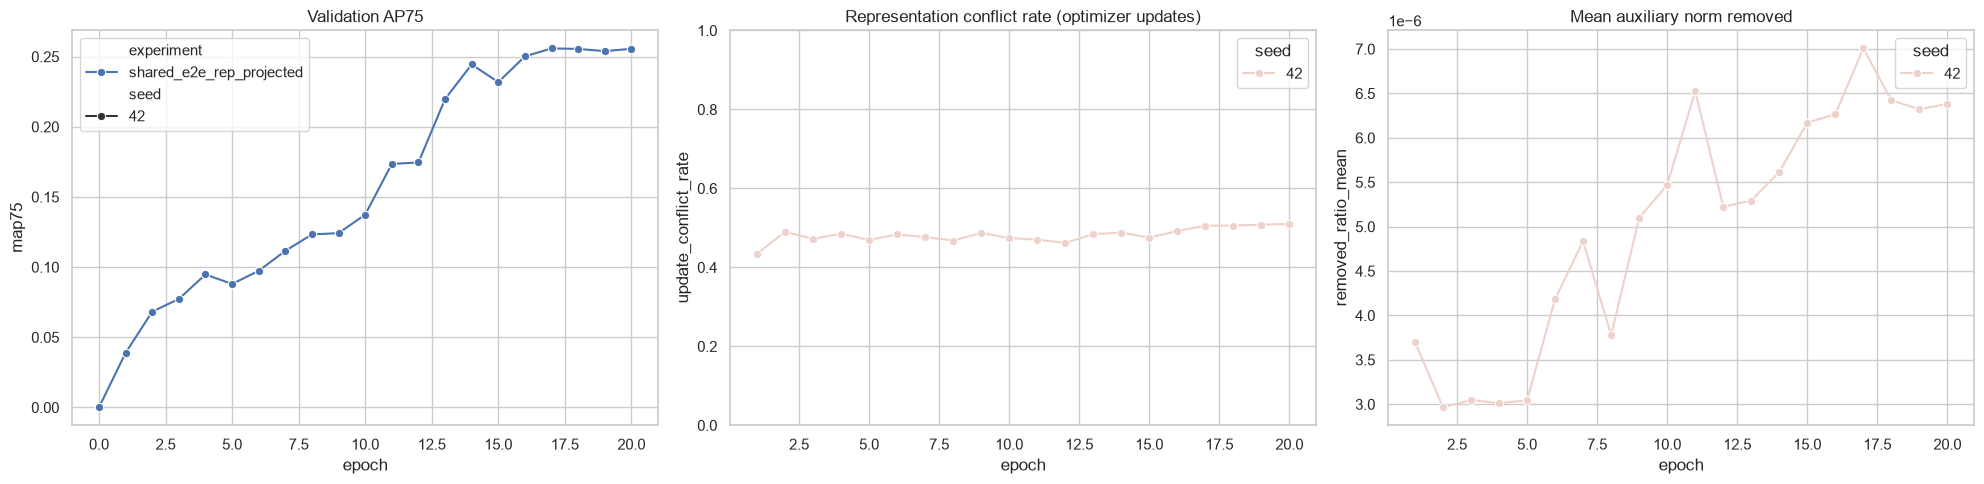

In [11]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.lineplot(data=history_df, x='epoch', y='map75', hue='experiment', style='seed', marker='o', ax=axes[0])
axes[0].set_title('Validation AP75')
sns.lineplot(data=mechanism_summary, x='epoch', y='update_conflict_rate', hue='seed', marker='o', ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title('Representation conflict rate (optimizer updates)')
sns.lineplot(data=mechanism_summary, x='epoch', y='removed_ratio_mean', hue='seed', marker='o', ax=axes[2])
axes[2].set_title('Mean auxiliary norm removed')
plt.tight_layout()
figure_path = CONFIG.output_dir / 'shared_e2e_rep_projected_training.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
print('Saved:', figure_path)
plt.show()